# Term Funding Premium (TFP) Swap Spread Screener

Implements the JPM framework from *"Term Funding Premium and the Term Structure of SOFR Swap Spreads"* (Apr 2024) and Dallas Fed WP 2613.

**TFP** = negative of the slope of a cross-sectional regression of maturity-matched swap spreads vs modified duration at benchmark tenors (2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y).

**ZDS** (zero-duration spread) = intercept of that regression.

**Deviation** = actual MMSS minus the fitted term-structure baseline. These deviations are mean-reverting and tradeable.

In [ ]:
import sys, os, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from BT.signals.tfp_swap_spread import (
    BENCHMARK_TENORS,
    REGRESSION_TENORS,
    compute_tfp_regression,
    build_tfp_history,
    compute_deviation_zscores,
    generate_signals,
    current_snapshot_table,
    deviation_heatmap_data,
    zscore_heatmap_data,
    diagnose_bond_resolution,
)
from RVUtils.plt_timeseries import make_secondary_axis_plot

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'medium',
    'figure.figsize': (18, 6),
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
})
%matplotlib inline

## Parameters

In [2]:
START_DATE = datetime.date(2025, 5, 1)
END_DATE = datetime.date(2026, 5, 14)

CURVE_NAME = 'USD-SOFR-1D'
ZSCORE_WINDOW = 60          # rolling window for z-scores (business days)
Z_ENTRY = 1.5               # entry threshold (standard deviations)
Z_EXIT = 0.0                # exit threshold (mean reversion to zero)

CACHE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener'))
CACHE_PATH = os.path.join(CACHE_DIR, 'tfp_history.parquet')

print(f'Period: {START_DATE} to {END_DATE}')
print(f'Cache:  {CACHE_PATH}')

Period: 2025-05-01 to 2026-05-14
Cache:  c:\Users\chris\clee\ARBS\BT\results\tfp_screener\tfp_history.parquet


## Initialize MDPs

In [3]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP

curve_mdp = IRSwapsMDP(source='ERIS_EOD_LIVE-RL_BASIC')
usts_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-RL')

## Build / Load Historical TFP Data

First run will compute from scratch and cache to parquet. Subsequent runs load cache and compute only new dates.

In [5]:
history = build_tfp_history(
    start_date=START_DATE,
    end_date=END_DATE,
    curve_mdp=curve_mdp,
    usts_mdp=usts_mdp,
    cache_path=CACHE_PATH,
    show_progress=True,
)
history = history.loc[START_DATE:END_DATE]
print(f'History: {len(history)} business days, {history.index.min()} to {history.index.max()}')
history

History: 260 business days, 2025-05-01 00:00:00 to 2026-05-14 00:00:00


,tfp,zds,slope,r_squared,mmss_10Y,dur_10Y,baseline_10Y,dev_10Y,mmss_20Y,dur_20Y,...,baseline_3Y,dev_3Y,mmss_5Y,dur_5Y,baseline_5Y,dev_5Y,mmss_7Y,dur_7Y,baseline_7Y,dev_7Y
date,,,,,,,,,,,,,,,,,,,,,
2025-05-01,4.785127,-16.393185,-4.785127,0.988259,-53.798426,7.783626,-53.638829,-0.159597,-81.633728,12.637244,...,-29.641447,-0.782885,-37.230928,4.502847,-37.939882,0.708954,-46.157000,6.046980,-45.328755,-0.828245
2025-05-02,4.841195,-15.626480,-4.841195,0.989879,-53.512938,7.765512,-53.220839,-0.292099,-81.073087,12.600197,...,-28.982248,-0.354953,-36.635212,4.491334,-37.369904,0.734692,-45.825871,6.033583,-44.836229,-0.989642
2025-05-05,4.936090,-15.693351,-4.936090,0.989538,-54.489467,7.758969,-53.992322,-0.497146,-81.994899,12.577578,...,-29.297872,-0.018453,-37.819961,4.488029,-37.846664,0.026703,-46.930955,6.029418,-45.455102,-1.475853
2025-05-06,4.928524,-16.340345,-4.928524,0.988213,-54.801160,7.761099,-54.591104,-0.210056,-82.907285,12.585533,...,-29.914450,-0.295669,-38.479462,4.486789,-38.453593,-0.025868,-47.560813,6.028977,-46.054302,-1.506511
2025-05-07,4.891961,-15.261036,-4.891961,0.987875,-53.515137,7.763687,-53.240692,-0.274446,-81.795792,12.605340,...,-28.722367,-0.528557,-36.712761,4.485317,-37.203034,0.490273,-45.793120,6.028838,-44.753879,-1.039241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-08,4.233703,-9.357732,-4.233703,0.988503,-41.404614,7.871864,-42.684869,1.280256,-67.133446,12.587843,...,-20.947098,0.126430,-28.513365,4.472641,-28.293565,-0.219800,-35.191996,5.994132,-34.735109,-0.456886
2026-05-11,4.259311,-11.659508,-4.259311,0.983230,-43.262718,7.863837,-45.154035,1.891317,-70.589922,12.564517,...,-23.303972,-0.496282,-30.265469,4.468177,-30.690861,0.425392,-37.939666,5.988699,-37.167239,-0.772427
2026-05-12,4.423271,-9.064528,-4.423271,0.982034,-41.864600,7.854808,-43.808471,1.943870,-70.223320,12.534090,...,-21.142438,0.222507,-28.263889,4.463940,-28.809743,0.545854,-36.921184,5.982626,-35.527303,-1.393882


## 1. Term Funding Premium (TFP) Time Series

TFP = -slope of the swap spread vs modified duration regression. Higher TFP means steeper inversion of the spread curve.

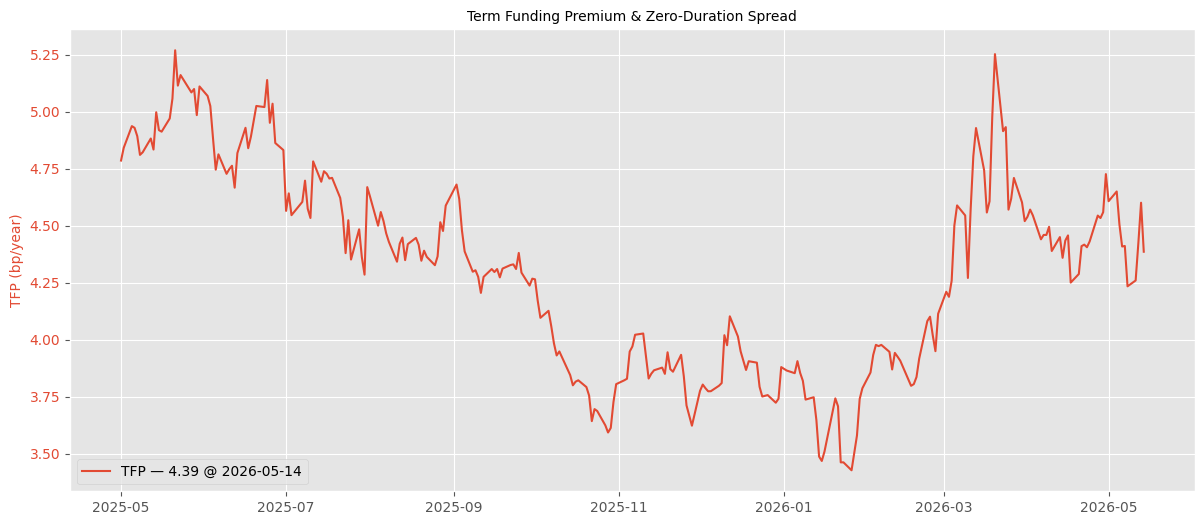

In [6]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left="TFP (bp/year)", ylabel_right="ZDS (bp)", title="Term Funding Premium & Zero-Duration Spread"
)

plot(history['tfp'].rename("TFP"), which="left", indicators=[
    # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
    # {"kind": "sma", "window": 60, "style": {"linestyle": "--"}},
    # {"kind": "simple_avg", "label": "TFP long-run mean", "style": {"linestyle": ":", "color": "blue"}},
    # {"kind": "hurst", "hide": True},
    # {"kind": "half_life", "hide": True},
	# {
	# 	"kind": "full_sigma", "n": 2, "hide_center": True,
	# 	"style_upper": {"linestyle": "--", "color": "cyan"},
	# 	"style_lower": {"linestyle": "--", "color": "cyan"},
	# },
])

# plot(history['zds'].rename("ZDS"), which="right", indicators=[
#     {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
#     {"kind": "sma", "window": 60, "style": {"linestyle": "--"}},
# ])

legend(show_date=True)
plt.show()

## 2. Maturity-Matched Swap Spreads by Tenor

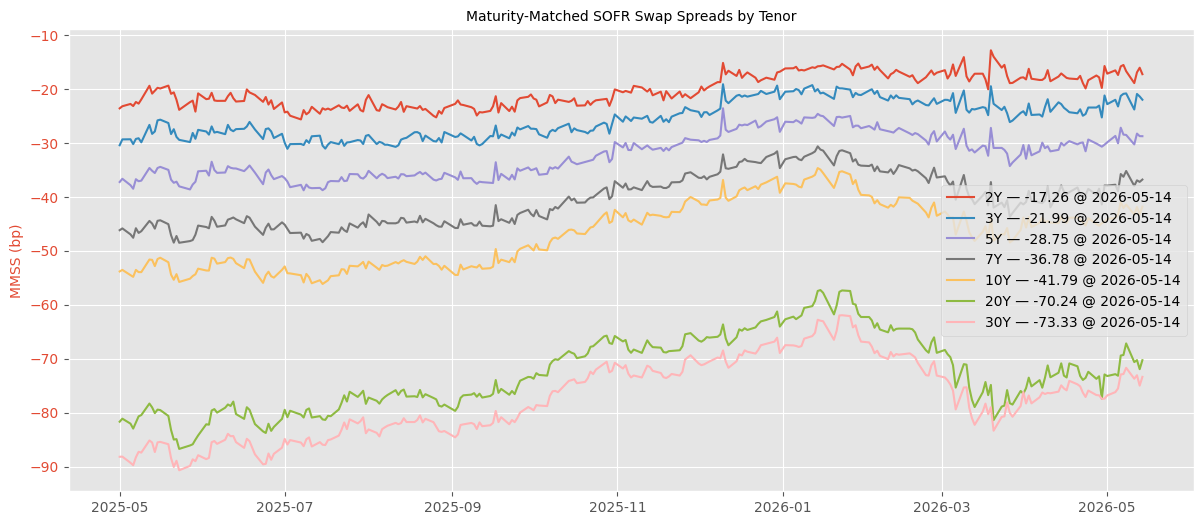

In [7]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left="MMSS (bp)", title="Maturity-Matched SOFR Swap Spreads by Tenor"
)

for tenor in BENCHMARK_TENORS:
    col = f'mmss_{tenor}'
    if col in history.columns:
        plot(history[col].rename(tenor), which="left", indicators=[
            # {"kind": "last", "hide": True},
        ])

legend(show_date=True)
plt.show()

## 3. Deviation from Term Structure - Heatmap

Deviation = actual MMSS minus term-structure baseline. Positive = spread narrower than expected. Negative = wider than expected.

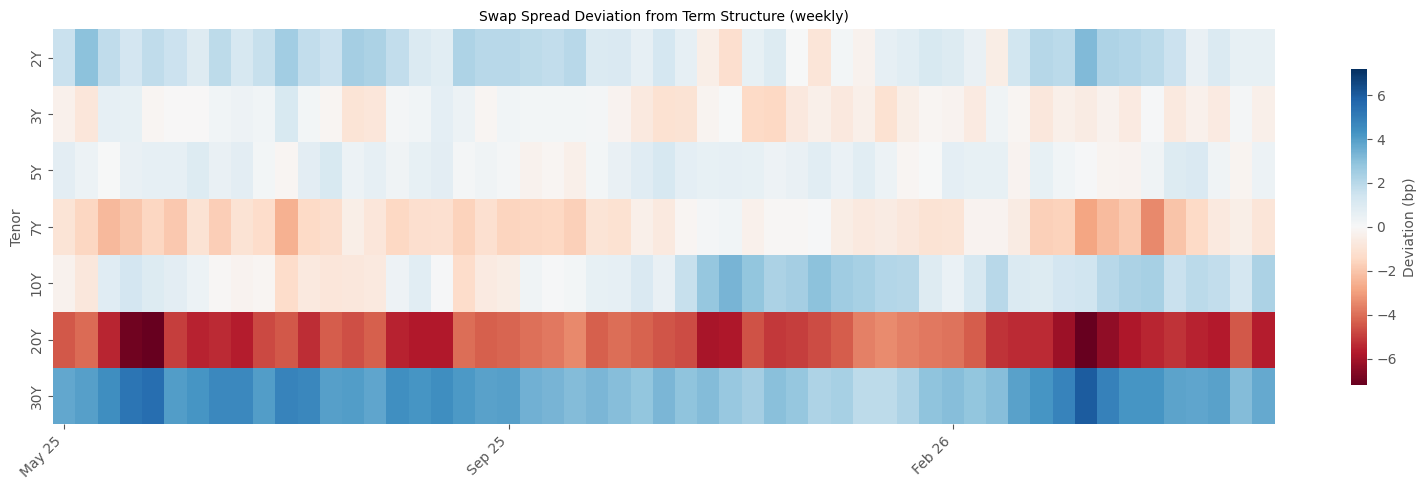

In [8]:
dev_heat = deviation_heatmap_data(history, resample='W')

fig, ax = plt.subplots(figsize=(16, 5))
vmax = max(abs(dev_heat.quantile(0.02).min()), abs(dev_heat.quantile(0.98).max()))
sns.heatmap(
    dev_heat.T,
    ax=ax,
    cmap='RdBu',
    center=0,
    vmin=-vmax,
    vmax=vmax,
    xticklabels=20,
    yticklabels=True,
    cbar_kws={'label': 'Deviation (bp)', 'shrink': 0.8},
)
ax.set_title('Swap Spread Deviation from Term Structure (weekly)')
ax.set_xlabel('')
ax.set_ylabel('Tenor')

xtick_labels = [dev_heat.index[int(i)].strftime('%b %y')
                if int(i) < len(dev_heat) else ''
                for i in ax.get_xticks()]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

fig.tight_layout()
plt.show()

## 4. Z-Score Heatmap

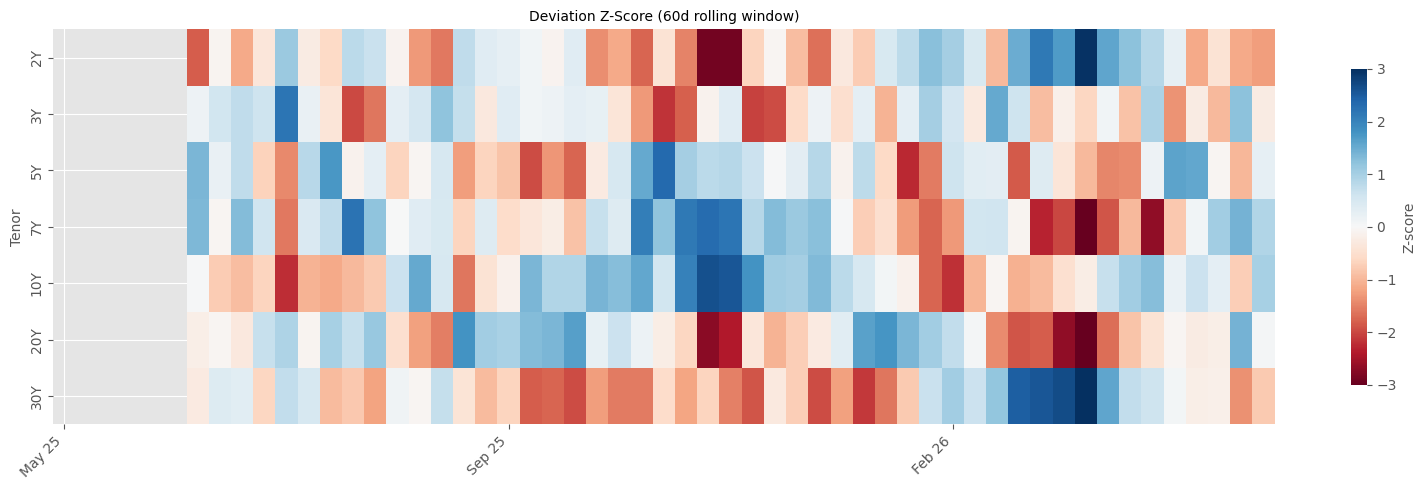

In [9]:
zscores = compute_deviation_zscores(history, window=ZSCORE_WINDOW)
z_heat = zscore_heatmap_data(zscores, resample='W')

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    z_heat.T,
    ax=ax,
    cmap='RdBu',
    center=0,
    vmin=-3,
    vmax=3,
    xticklabels=20,
    yticklabels=True,
    cbar_kws={'label': 'Z-score', 'shrink': 0.8},
)
ax.set_title(f'Deviation Z-Score ({ZSCORE_WINDOW}d rolling window)')
ax.set_xlabel('')
ax.set_ylabel('Tenor')

xtick_labels = [z_heat.index[int(i)].strftime('%b %y')
                if int(i) < len(z_heat) else ''
                for i in ax.get_xticks()]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

fig.tight_layout()
plt.show()

## 5. Current Snapshot

In [10]:
latest = history.iloc[-1]
print(f"As of: {history.index[-1]}")
print(f"TFP:   {latest['tfp']:.2f} bp/year")
print(f"ZDS:   {latest['zds']:.1f} bp")
print(f"R^2:   {latest['r_squared']:.1%}")
print()

# Build snapshot table with z-scores
rows = []
latest_z = zscores.iloc[-1] if len(zscores) > 0 else pd.Series(dtype=float)
for t in BENCHMARK_TENORS:
    row = {
        'Tenor': t,
        'MMSS (bp)': round(latest.get(f'mmss_{t}', float('nan')), 1),
        'Mod Dur': round(latest.get(f'dur_{t}', float('nan')), 1),
        'Baseline (bp)': round(latest.get(f'baseline_{t}', float('nan')), 1),
        'Dev (bp)': round(latest.get(f'dev_{t}', float('nan')), 1),
        'Z-score': round(latest_z.get(f'z_{t}', float('nan')), 2),
    }
    rows.append(row)

snapshot_df = pd.DataFrame(rows).set_index('Tenor')
snapshot_df.style.background_gradient(
    subset=['Dev (bp)', 'Z-score'],
    cmap='RdBu',
    vmin=-3, vmax=3,
)

As of: 2026-05-14 00:00:00
TFP:   4.39 bp/year
ZDS:   -9.6 bp
R^2:   98.3%



,MMSS (bp),Mod Dur,Baseline (bp),Dev (bp),Z-score
Tenor,,,,,
2Y,-17.300000,1.900000,-17.800000,0.600000,-1.250000
3Y,-22.000000,2.700000,-21.600000,-0.400000,-0.240000
5Y,-28.700000,4.500000,-29.200000,0.400000,0.260000
7Y,-36.800000,6.000000,-35.900000,-0.900000,0.910000
10Y,-41.800000,7.900000,-44.100000,2.300000,1.010000
20Y,-70.200000,12.500000,-64.600000,-5.600000,0.060000
30Y,-73.300000,15.400000,-77.000000,3.700000,-0.780000


## 6. Current Cross-Sectional Regression

Scatter of maturity-matched swap spread vs modified duration with fitted line.

## 5b. Bond Resolution Diagnostic

Shows which CUSIPs the CT aliases resolve to. Verify mod durations match Bloomberg/JPM for cross-checking term structure fit quality.

In [ ]:
diag = diagnose_bond_resolution(END_DATE, usts_mdp=usts_mdp)
print(f"Regression tenors (used in OLS): {REGRESSION_TENORS}")
print(f"20Y excluded — large ERIS/BBG duration mismatch distorts long-end fit\n")
diag

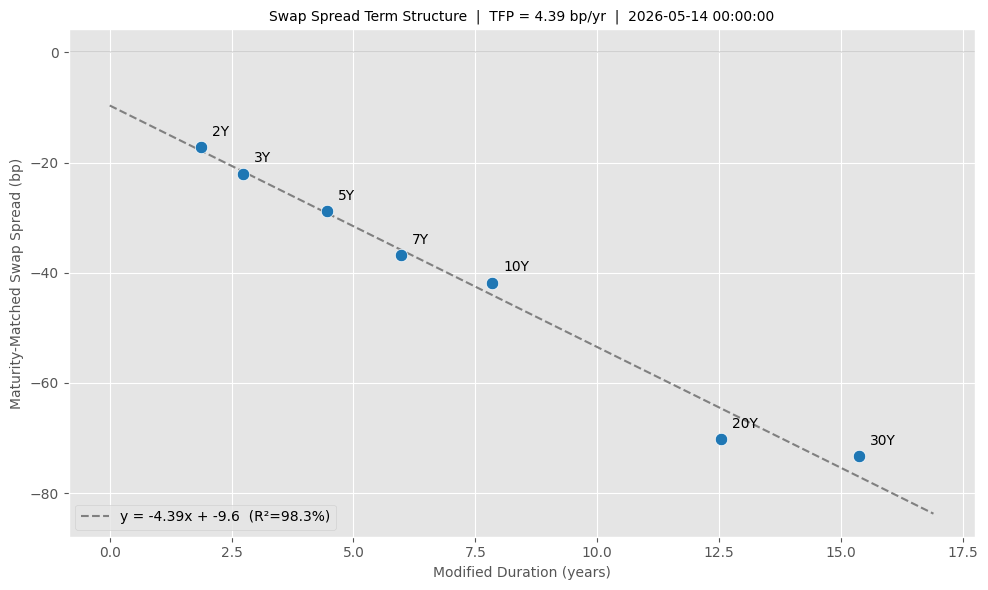

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

durations = []
spreads = []
labels = []
for t in BENCHMARK_TENORS:
    d = latest.get(f'dur_{t}')
    s = latest.get(f'mmss_{t}')
    if pd.notna(d) and pd.notna(s):
        durations.append(d)
        spreads.append(s)
        labels.append(t)

ax.scatter(durations, spreads, s=80, zorder=5, color='#1f77b4', edgecolors='white')
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (durations[i], spreads[i]),
                textcoords='offset points', xytext=(8, 8), fontsize=10)

# Fitted line
x_fit = np.linspace(0, max(durations) * 1.1, 100)
y_fit = latest['slope'] * x_fit + latest['zds']
ax.plot(x_fit, y_fit, '--', color='grey', linewidth=1.5,
        label=f'y = {latest["slope"]:.2f}x + {latest["zds"]:.1f}  (R\u00b2={latest["r_squared"]:.1%})')

ax.axhline(0, color='grey', linewidth=0.3)
ax.set_xlabel('Modified Duration (years)')
ax.set_ylabel('Maturity-Matched Swap Spread (bp)')
ax.set_title(f'Swap Spread Term Structure  |  TFP = {latest["tfp"]:.2f} bp/yr  |  {history.index[-1]}')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

## 7. TFP Regime Stats

In [12]:
tfp_stats = history[['tfp', 'zds', 'r_squared']].describe().T
tfp_stats['current'] = [latest['tfp'], latest['zds'], latest['r_squared']]
tfp_stats['pctile'] = [
    (history['tfp'] <= latest['tfp']).mean(),
    (history['zds'] <= latest['zds']).mean(),
    (history['r_squared'] <= latest['r_squared']).mean(),
]
tfp_stats[['current', 'mean', 'std', 'min', 'max', 'pctile']].round(2)

,current,mean,std,min,max,pctile
tfp,4.39,4.31,0.44,3.43,5.27,0.53
zds,-9.64,-13.41,3.09,-18.44,-5.29,0.88
r_squared,0.98,0.98,0.00,0.96,0.99,0.20


## 8. Signal Summary

Mean-reversion signals: enter when |z| > threshold, exit at z = 0.

In [13]:
signals = generate_signals(zscores, z_entry=Z_ENTRY, z_exit=Z_EXIT)

# Current signal state
current_signals = signals.iloc[-1] if len(signals) > 0 else pd.Series(dtype=int)
sig_map = {-1: 'PAY spread', 0: 'FLAT', 1: 'RECEIVE spread'}

print(f'Signal thresholds: entry |z| > {Z_ENTRY}, exit z -> {Z_EXIT}')
print(f'As of: {signals.index[-1]}\n')

for t in BENCHMARK_TENORS:
    col = f'sig_{t}'
    if col in current_signals.index:
        val = int(current_signals[col])
        z_val = latest_z.get(f'z_{t}', float('nan'))
        marker = '>>>' if val != 0 else '   '
        print(f'{marker} {t:>4s}:  z={z_val:+.2f}  signal={sig_map[val]}')

Signal thresholds: entry |z| > 1.5, exit z -> 0.0
As of: 2026-05-14 00:00:00

      2Y:  z=-1.25  signal=FLAT
      3Y:  z=-0.24  signal=FLAT
      5Y:  z=+0.26  signal=FLAT
      7Y:  z=+0.91  signal=FLAT
     10Y:  z=+1.01  signal=FLAT
     20Y:  z=+0.06  signal=FLAT
     30Y:  z=-0.78  signal=FLAT


## 9. Deviation Time Series by Tenor

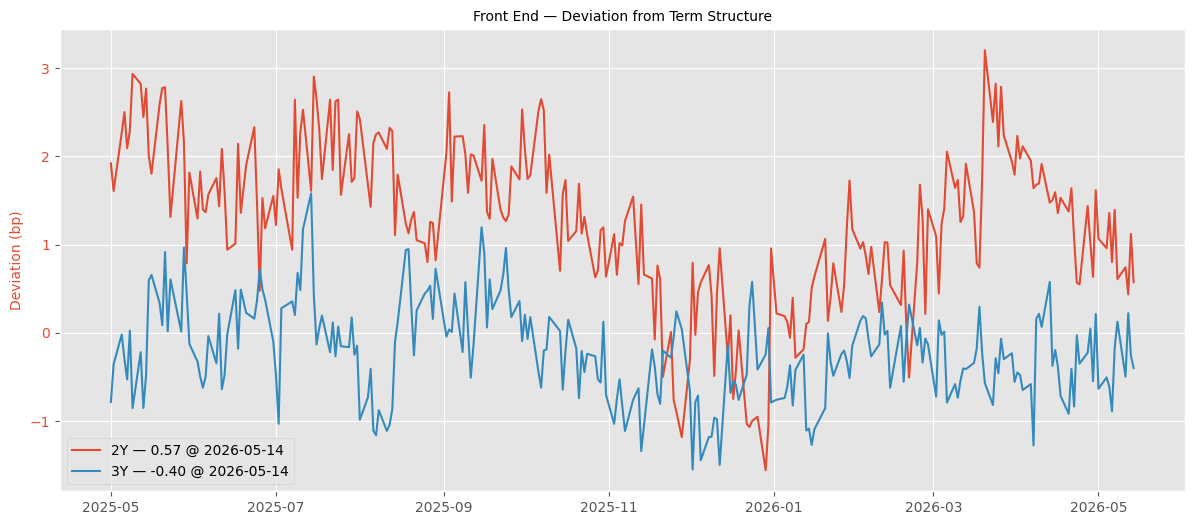

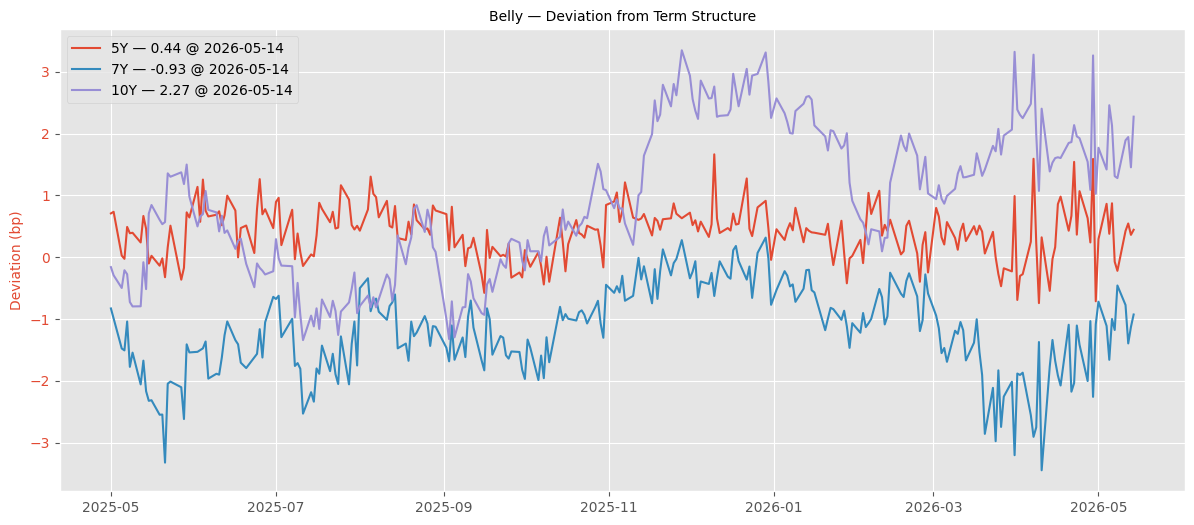

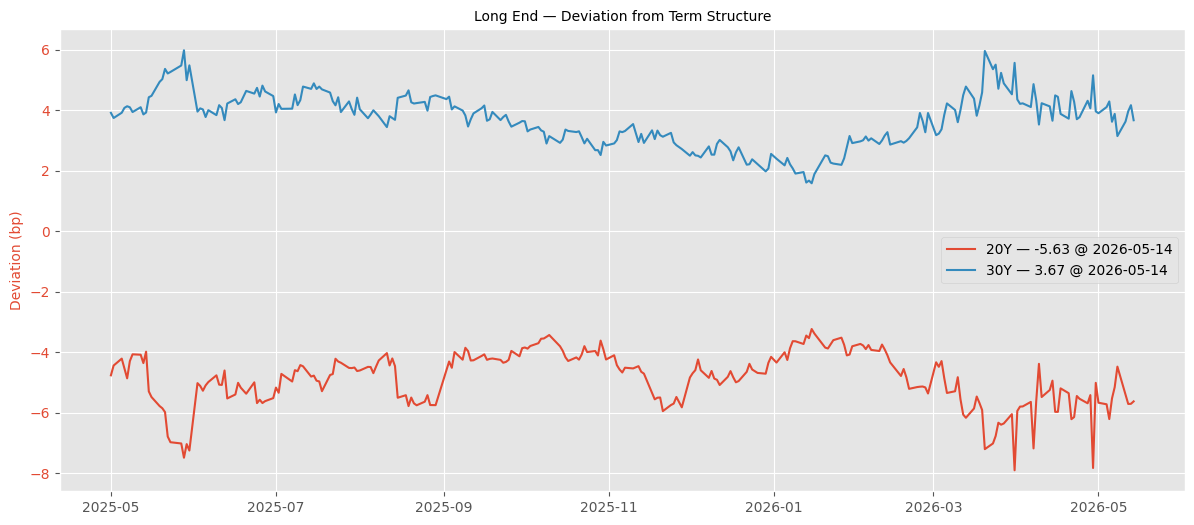

In [14]:
for tenors_group, title in [(['2Y','3Y'], 'Front End'), (['5Y','7Y','10Y'], 'Belly'), (['20Y','30Y'], 'Long End')]:
    plot, fig, ax, ax2, legend = make_secondary_axis_plot(
        ylabel_left="Deviation (bp)", title=f"{title} — Deviation from Term Structure"
    )
    for t in tenors_group:
        col = f'dev_{t}'
        if col in history.columns:
            plot(history[col].rename(t), which="left", indicators=[
                # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
                # {"kind": "simple_avg", "style": {"linestyle": ":", "color": "grey"}},
                # {"kind": "hurst", "hide": True},
                # {"kind": "half_life", "hide": True},
                # {
                #     "kind": "full_sigma", "n": 2, "hide_center": True,
                #     "style_upper": {"linestyle": "--", "color": "cyan"},
                #     "style_lower": {"linestyle": "--", "color": "cyan"},
                # },
            ])
    legend(show_date=True)
    plt.show()

## 10. R-squared History

Quality of the cross-sectional fit over time.

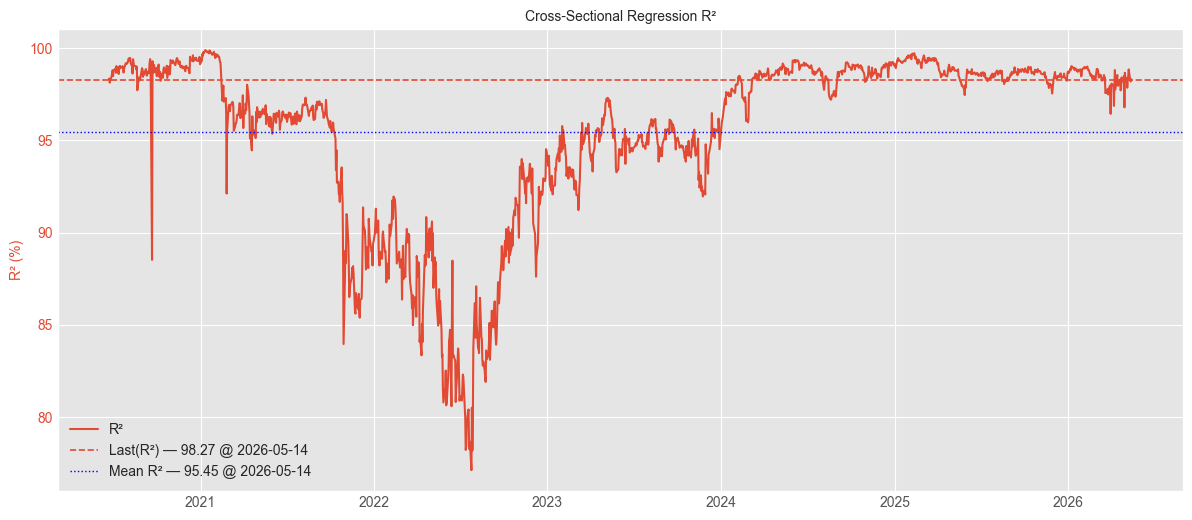

In [31]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left="R² (%)", title="Cross-Sectional Regression R²"
)

plot((history['r_squared'] * 100).rename("R²"), which="left", indicators=[
    {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
    {"kind": "simple_avg", "label": "Mean R²", "style": {"linestyle": ":", "color": "blue"}},
])

legend(show_date=True)
plt.show()